### Create the MIST Geometry Using Techniques from `planning.ipynb`

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle

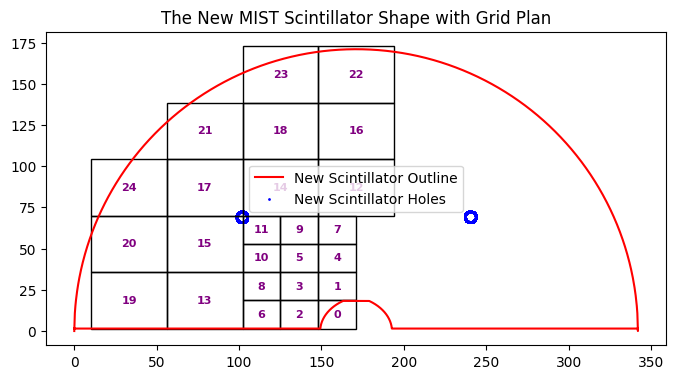

In [4]:
line1 = [np.linspace(0,171-21.75,1000),np.full(1000,1.5)]
xi,yi = -np.sqrt(21.75**2-1.5**2), 1.5
xf,yf = 171-15.69/2,18.3
line2 = [np.linspace(171+xi,xf,1000),np.array([np.sqrt(21.75**2-x**2) for x in np.linspace(xi,-np.sqrt(21.75**2-18.3**2),1000)])]
line3 = [np.linspace(xf,171+15.69/2,1000),np.full(1000,yf)]

xf,yf = np.sqrt(21.75**2-1.5**2), 1.5
xi,yi = 171+15.69/2,18.3
line4 = [np.linspace(xi,171+xf,1000),np.array([np.sqrt(21.75**2-x**2) for x in np.linspace(np.sqrt(21.75**2-18.3**2),xf,1000)])]
line5 = [np.linspace(171+21.75,342,1000),np.full(1000,1.5)]

line6 = [np.linspace(0,342,1000),np.array([np.sqrt(171**2-x**2) for x in np.linspace(-171,171,1000)])]

new_scint = np.concatenate((line1, line2, line3, line4, line5, np.flip(line6, axis=1)), axis=1)

r = 3.3
circ = np.transpose(np.array([r * np.array([np.cos(theta), np.sin(theta)]) for theta in np.linspace(0, 2*np.pi, 1000)]))
line7 = circ + np.transpose(np.full((1000, 2), [171-69.3, 69.3]))
line8 = circ + np.transpose(np.full((1000, 2), [171+69.3, 69.3]))

holes = np.concatenate((line7, line8), axis=1)


fig, ax = plt.subplots(figsize=(8, 8))
patches = []

width = 22.96
height = 17.14
centre_range = 4

# Base large dimensions
width *= 2
height *= 2

rows = round(171/height)
cols = round(342/width)
centring_correction = (cols*width - 342)/2

# --- 1. POPULATE PATCHES WITH CORRECT COORDINATE MATH ---
for row in range(rows):
    for col in range(cols):
        # Determine if we are in the middle-third horizontally and bottom-third vertically
        if (col > cols/centre_range and col < (round(centre_range/2))*cols/centre_range) and (row < rows/centre_range):
            
            # Base offsets for this specific grid cell
            x_base = col * width - centring_correction
            y_base = row * height + 1.5
            
            w_sub = width / 2
            h_sub = height / 2
            
            # Bottom-left sub-rectangle
            patches.append(Rectangle((x_base, y_base), w_sub, h_sub))
            # Bottom-right sub-rectangle
            patches.append(Rectangle((x_base + w_sub, y_base), w_sub, h_sub))
            # Top-left sub-rectangle
            patches.append(Rectangle((x_base, y_base + h_sub), w_sub, h_sub))
            # Top-right sub-rectangle
            patches.append(Rectangle((x_base + w_sub, y_base + h_sub), w_sub, h_sub))
        else:
            patches.append(Rectangle((col * width - centring_correction, row * height + 1.5), width, height))

# --- 2. FILTER AND TRACK DYNAMIC DIMENSIONS ---
target_center, target_range = np.array([171, 1.5]), 170
new_box_data = []

for patch in patches:
    # Safely extract the custom width and height of THIS specific rectangle
    w = patch.get_width()
    h = patch.get_height()
    
    x, y = patch.get_xy()
    x_c = x + w / 2
    y_c = y + h / 2
    x_shift = x + w

    # Out of circular boundary check
    if np.linalg.norm(np.array([x_c, y_c]) - target_center) > target_range:
        continue
    # Bottom cutout check
    if y == 1.5 and (x > 171-21.75 and x < 171+21.75) and (x_shift > 171-21.75 and x_shift < 171+21.75):
        continue
    # Right-hand side removal constraint
    if x_c > 171:
        continue

    # Calculate distance for sorting
    distance = np.linalg.norm(np.array([x_c, y_c]) - target_center)
    
    new_box_data.append({
        'xy': (x, y),
        'w': w,
        'h': h,
        'centre': (x_c, y_c),
        'distance': distance
    })

# Sort by distance from target center
new_box_data.sort(key=lambda item: item['distance'])

# --- 3. PLOT AND LABEL ---
plt.title("The New MIST Scintillator Shape with Grid Plan")
plt.plot(new_scint[0], new_scint[1], label="New Scintillator Outline", color='red')
plt.scatter(holes[0], holes[1], label="New Scintillator Holes", s=1, color='blue')

# Redraw the filtered patches using their unique stored sizes
for box_id, data in enumerate(new_box_data):
    x, y = data['xy']
    w, h = data['w'],data['h']
    x_c, y_c = data['centre']
    
    # Draw the rectangle with its exact individual size
    rect = Rectangle((x, y), w, h, facecolor='none', edgecolor='black')
    ax.add_patch(rect)
    
    # Place text exactly at the calculated center
    ax.text(x_c, y_c, str(box_id), color='purple', fontsize=8,
            ha='center', va='center', weight='bold')

ax = plt.gca()
ax.set_aspect('equal')
plt.legend()
plt.show()

-10.280000000000001
20
Box 0 has centre at (33.24, 34.14)
Box 1 has centre at (308.75999999999993, 34.14)
Box 2 has centre at (262.84000000000003, 34.14)
Box 3 has centre at (79.16, 34.14)
Box 4 has centre at (216.92000000000002, 34.14)
Box 5 has centre at (125.08000000000001, 34.14)
Box 6 has centre at (171.0, 34.14)
Box 7 has centre at (262.84000000000003, 68.42)
Box 8 has centre at (79.16, 68.42)
Box 9 has centre at (216.92000000000002, 68.42)
Box 10 has centre at (125.08000000000001, 68.42)
Box 11 has centre at (171.0, 68.42)
Box 12 has centre at (262.84000000000003, 102.7)
Box 13 has centre at (79.16, 102.7)
Box 14 has centre at (216.92000000000002, 102.7)
Box 15 has centre at (125.08000000000001, 102.7)
Box 16 has centre at (171.0, 102.7)
Box 17 has centre at (216.92000000000002, 136.98000000000002)
Box 18 has centre at (125.08000000000001, 136.98000000000002)
Box 19 has centre at (171.0, 136.98000000000002)


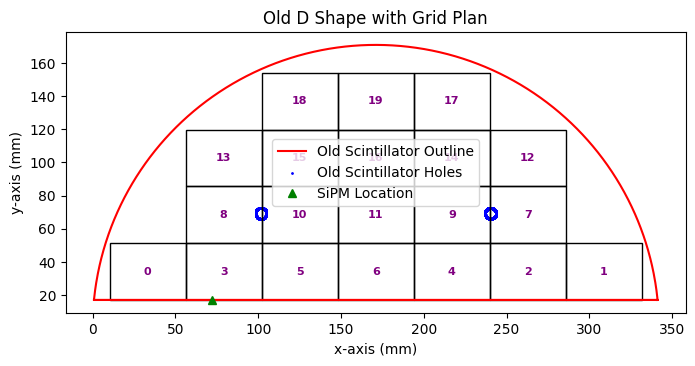

Number of boxes: 20


In [5]:
def circle(radius):
   return np.transpose(np.array([radius * np.array([np.cos(theta), np.sin(theta)]) for theta in np.linspace(0, 2*np.pi, 1000)]))

R = 171
h = 17

xi,xf = -np.sqrt(R**2-h**2) + R, np.sqrt(R**2-h**2) + R, 
X_centre = np.sqrt(R**2-h**2)+xi

line1 = [np.linspace(xi,xf,1000),np.full(1000,h)]

line2 = [np.linspace(xi,xf,1000),np.array([np.sqrt(171**2-x**2) for x in np.linspace(xi-R,xf-R,1000)])]

old_scint = np.concatenate((line1, line2), axis=1)

circ = circle(3.3)
line7 = circ + np.transpose(np.full((1000, 2), [171-69.3, 69.3]))
line8 = circ + np.transpose(np.full((1000, 2), [171+69.3, 69.3]))

holes = np.concatenate((line7, line8), axis=1)

SiPM_loc = [65+7,h]

fig, ax = plt.subplots(figsize=(8, 8))
patches = []

tolerance = 0.9
scale_factor = 0.75

width = 22.96
height = 17.14
centre_range = 4

# Base large dimensions
width *= 2
height *= 2

rows = round(R/height)
cols = round(2*R/width)
centring_correction = (cols*width - X_centre*2)/2
print(centring_correction)

# --- 1. POPULATE PATCHES WITH CORRECT COORDINATE MATH ---
for row in range(rows):
    for col in range(cols):
        x,y = col * width - centring_correction, row * height + h
        x_c = x + width / 2
        y_c = y + height / 2
        dist = np.linalg.norm([x_c,y_c] - target_center)
        patches.append(Rectangle((x,y), width, height))

# --- 2. FILTER AND TRACK DYNAMIC DIMENSIONS ---
target_center, target_range = np.array([R, 0]), R
old_box_data = []

for patch in patches:
    # Safely extract the custom width and height of THIS specific rectangle
    w = patch.get_width()
    h = patch.get_height()
    
    x, y = patch.get_xy()
    x_c = x + w / 2
    y_c = y + h / 2
    x_shift = x + w
    y_shift = y + h

    # Out of circular boundary check
    if np.linalg.norm(np.array([x, y_shift]) - target_center) > target_range or np.linalg.norm(np.array([x_shift, y_shift]) - target_center) > target_range:
        continue
    # Bottom cutout check
    if y == 1.5 and (x > 171-21.75 and x < 171+21.75) and (x_shift > 171-21.75 and x_shift < 171+21.75):
        continue
    # Right-hand side removal constraint
    # if x_c > 171:
    #     continue

    # Calculate distance for sorting
    distance = np.linalg.norm(np.array([x_c, y_c]) - target_center)
    
    old_box_data.append({
        'xy': (x, y),
        'w': w,
        'h': h,
        'centre': (x_c, y_c),
        'distance': distance
    })

print(len(old_box_data))

# Sort by distance from target center
# box_data.sort(key=lambda item: item['distance'], reverse=True)
old_box_data.sort(key=lambda item: (item['xy'][1], -item['distance']))

# Make scaled down model
tc_col = target_center.reshape(2, 1)
scaled_scint = tc_col + scale_factor * (old_scint - tc_col)
scaled_holes = tc_col + scale_factor * (holes - tc_col)

# --- 3. PLOT AND LABEL ---
plt.title("Old D Shape with Grid Plan")
plt.plot(old_scint[0], old_scint[1], label="Old Scintillator Outline", color='red')
plt.scatter(holes[0], holes[1], label="Old Scintillator Holes", s=1, color='blue')

# Redraw the filtered patches using their unique stored sizes
for box_id, data in enumerate(old_box_data):
    x, y = data['xy']
    w, h = data['w'],data['h']
    x_c, y_c = data['centre']
    print(f"Box {box_id} has centre at ({x_c}, {y_c})")
    
    # Draw the rectangle with its exact individual size
    rect = Rectangle((x, y), w, h, facecolor='none', edgecolor='black')
    ax.add_patch(rect)
    
    # Place text exactly at the calculated center
    ax.text(x_c, y_c, str(box_id), color='purple', fontsize=8,
            ha='center', va='center', weight='bold')

ax = plt.gca()
ax.set_aspect('equal')
plt.plot(SiPM_loc[0],SiPM_loc[1],label='SiPM Location',color='green',linestyle='',marker='^')
plt.legend()
plt.xlabel('x-axis (mm)')
plt.ylabel('y-axis (mm)')
# plt.ylim(0,342)
plt.show()

print(f"Number of boxes: {len(old_box_data)}")

20


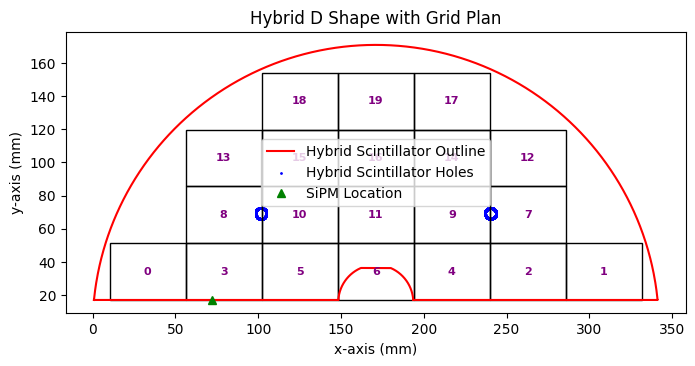

Number of boxes: 20


In [6]:
def circle(radius):
   return np.transpose(np.array([radius * np.array([np.cos(theta), np.sin(theta)]) for theta in np.linspace(0, 2*np.pi, 1000)]))

circ = circle(3.3)
line7 = circ + np.transpose(np.full((1000, 2), [171-69.3, 69.3]))
line8 = circ + np.transpose(np.full((1000, 2), [171+69.3, 69.3]))

holes = np.concatenate((line7, line8), axis=1)


45.2, 19.64, 17.1
r_0 = 21.75
h_0 = 18.4
h_m = 19.64
l_0 = 15.69
l_min, l_max = 16.94, 19.64
w_0 = 2*(np.sqrt(r_0**2-1.5**2))
w_m = 45.2
r_0 = 21.75

delta = 0.036*25.4
w = w_0+2*delta
h = h_0+delta
r = r_0+delta
l = 2*np.sqrt(r**2-h**2)

R = 171
H = 17
d = 1.5
SiPM_loc = [65+7,H]

xi,xf = -np.sqrt(R**2-H**2) + R, np.sqrt(R**2-H**2) + R,
W = xf-xi
c = W/2+xi
line1 = [np.linspace(xi,c-w/2,1000),np.full(1000,H)]
line2 = [np.linspace(c+w/2,xf,1000),np.full(1000,H)]

line3 = [np.linspace(xf,xi,1000),np.array([np.sqrt(R**2-x**2) for x in np.linspace(xf-R,xi-R,1000)])]

start,stop = np.sqrt(r**2-d**2), np.sqrt(r**2-(h+d)**2),
line4 = [np.linspace(c-start,c-stop,1000),np.array([np.sqrt(r**2-x**2)+H-d for x in np.linspace(start,stop,1000)])]
line5 = [np.linspace(c+start,c+stop,1000)[::-1],np.array([np.sqrt(r**2-x**2)+H-d for x in np.linspace(start,stop,1000)])[::-1]]
line6 = [np.linspace(c-stop,c+stop,1000),np.full(1000,H+h)]


hybrid_scint = np.concatenate((line1, line4, line6, line5, line2, line3), axis=1)

fig, ax = plt.subplots(figsize=(8, 8))
patches = []

R,h = 171, 17
xi,xf = -np.sqrt(R**2-h**2) + R, np.sqrt(R**2-h**2) + R, 
X_centre = np.sqrt(R**2-h**2)+xi

tolerance = 0.9
scale_factor = 0.75

width = 22.96
height = 17.14
centre_range = 4

# Base large dimensions
width *= 2
height *= 2

rows = round(R/height)
cols = round(2*R/width)
centring_correction = (cols*width - X_centre*2)/2

# --- 1. POPULATE PATCHES WITH CORRECT COORDINATE MATH ---
for row in range(rows):
    for col in range(cols):
        x,y = col * width - centring_correction, row * height + h
        x_c = x + width / 2
        y_c = y + height / 2
        dist = np.linalg.norm([x_c,y_c] - target_center)
        patches.append(Rectangle((x,y), width, height))

# --- 2. FILTER AND TRACK DYNAMIC DIMENSIONS ---
target_center, target_range = np.array([R, 0]), R
hybrid_box_data = []

for patch in patches:
    # Safely extract the custom width and height of THIS specific rectangle
    w = patch.get_width()
    h = patch.get_height()
    
    x, y = patch.get_xy()
    x_c = x + w / 2
    y_c = y + h / 2
    x_shift = x + w
    y_shift = y + h

    # Out of circular boundary check
    if np.linalg.norm(np.array([x, y_shift]) - target_center) > target_range or np.linalg.norm(np.array([x_shift, y_shift]) - target_center) > target_range:
        continue
    # Bottom cutout check
    if y == 1.5 and (x > 171-21.75 and x < 171+21.75) and (x_shift > 171-21.75 and x_shift < 171+21.75):
        continue
    # Right-hand side removal constraint
    # if x_c > 171:
    #     continue

    # Calculate distance for sorting
    distance = np.linalg.norm(np.array([x_c, y_c]) - target_center)
    
    hybrid_box_data.append({
        'xy': (x, y),
        'w': w,
        'h': h,
        'centre': (x_c, y_c),
        'distance': distance
    })

print(len(hybrid_box_data))

# Sort by distance from target center
# box_data.sort(key=lambda item: item['distance'], reverse=True)
hybrid_box_data.sort(key=lambda item: (item['xy'][1], -item['distance']))

# Make scaled down model
tc_col = target_center.reshape(2, 1)
scaled_scint = tc_col + scale_factor * (hybrid_scint - tc_col)
scaled_holes = tc_col + scale_factor * (holes - tc_col)

# --- 3. PLOT AND LABEL ---
plt.title("Hybrid D Shape with Grid Plan")
plt.plot(hybrid_scint[0], hybrid_scint[1], label="Hybrid Scintillator Outline", color='red')
plt.scatter(holes[0], holes[1], label="Hybrid Scintillator Holes", s=1, color='blue')

# Redraw the filtered patches using their unique stored sizes
for box_id, data in enumerate(hybrid_box_data):
    x, y = data['xy']
    w, h = data['w'],data['h']
    x_c, y_c = data['centre']
    
    # Draw the rectangle with its exact individual size
    rect = Rectangle((x, y), w, h, facecolor='none', edgecolor='black')
    ax.add_patch(rect)
    
    # Place text exactly at the calculated center
    ax.text(x_c, y_c, str(box_id), color='purple', fontsize=8,
            ha='center', va='center', weight='bold')

ax = plt.gca()
ax.set_aspect('equal')
plt.plot(SiPM_loc[0],SiPM_loc[1],label='SiPM Location',color='green',linestyle='',marker='^')
plt.legend()
plt.xlabel('x-axis (mm)')
plt.ylabel('y-axis (mm)')
# plt.ylim(0,342)
plt.show()

print(f"Number of boxes: {len(hybrid_box_data)}")

### Scintillator Placements:

In [14]:
id = 0

print("          | Horizontal Distance |   Vertical distance   |  Size of  |          |")
print("    ID    | from Left Edge (mm) | from Bottom Edge (mm) | Rectangle | Rotation |")
print("----------+---------------------+-----------------------+-----------+----------|")
print(f" baseline |                {SiPM_loc[0]-width/2:.1f} |                   0.0 |     Large |       0° |")

for box in old_box_data:
    x, y = box['xy']
    w, h = box['w'], box['h']
    rot = False
    if w == width:
        size='Large'
    elif w == width/2:
        size='Small'
    elif w == height/2:
        size='Small'
        rot=True
    else:
        size='Unknown'
    print(f" {id:8d} | {x:19.1f} | {y-17:21.1f} | {size:>9} | {"90°" if rot else "0°":>8} |")
    id+=1

          | Horizontal Distance |   Vertical distance   |  Size of  |          |
    ID    | from Left Edge (mm) | from Bottom Edge (mm) | Rectangle | Rotation |
----------+---------------------+-----------------------+-----------+----------|
 baseline |                49.0 |                   0.0 |     Large |       0° |
        0 |                10.3 |                   0.0 |     Large |       0° |
        1 |               285.8 |                   0.0 |     Large |       0° |
        2 |               239.9 |                   0.0 |     Large |       0° |
        3 |                56.2 |                   0.0 |     Large |       0° |
        4 |               194.0 |                   0.0 |     Large |       0° |
        5 |               102.1 |                   0.0 |     Large |       0° |
        6 |               148.0 |                   0.0 |     Large |       0° |
        7 |               239.9 |                  34.3 |     Large |       0° |
        8 |                5

### Detection Efficiency as a Function of Position in the MIST
A little more work, but fairly important

### Timing Resolution
A little more work, not that necessary (basically bonus)